In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
# from sklearn.model_selection import train_test_split
import tensorflow
import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


### Regression Problem

In [6]:
# Generating Data
import numpy as np

X_train = np.linspace(-1, 1, 20)

y_train = np.array([
    -0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
    0.5524, 0.23115, 0.20835, 0.4211, 0.60485
])

X_test = np.linspace(-1, 1, 20)

y_test = np.array([
    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
])

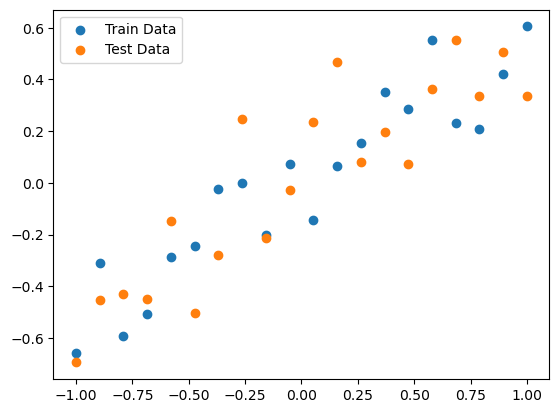

In [ ]:
# Plot the data
plt.scatter(X_train , y_train , label='Train Data')
plt.scatter(X_test , y_test , label='Test Data')
plt.legend()
plt.show()

In [28]:
# Building the model
model = Sequential()
model.add(Dense(256 , activation='relu' , input_dim = 1))
model.add(Dense(128 , activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(1 , activation='linear'))

model.summary()

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,537 (131.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam , metrics=['mse'])
history = model.fit(X_train,y_train,validation_data=(X_test,y_test) , epochs=500 , verbose=1)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step - loss: 0.1123 - mse: 0.1123 - val_loss: 0.0333 - val_mse: 0.0333
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0211 - mse: 0.0211 - val_loss: 0.0398 - val_mse: 0.0398
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0274 - mse: 0.0274 - val_loss: 0.0307 - val_mse: 0.0307
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0178 - mse: 0.0178 - val_loss: 0.0381 - val_mse: 0.0381
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0242 - mse: 0.0242 - val_loss: 0.0311 - val_mse: 0.0311
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0176 - mse: 0.0176 - val_loss: 0.0308 - val_mse: 0.0308
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0178 - mse: 0.0178 - val_loss: 0.0322 - val_mse: 0.0322
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0191 - mse: 0.0191 - val_loss: 0.0298 - val_mse: 0.0298
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0162 - mse:

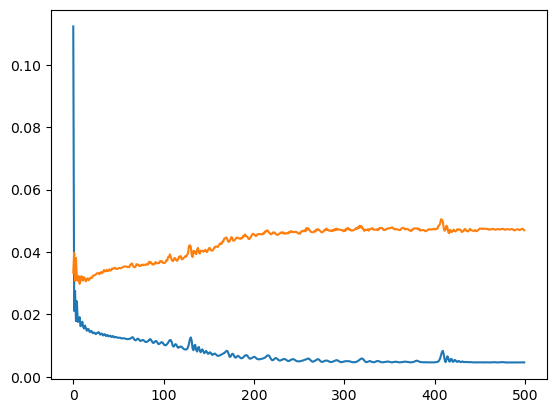

In [30]:
# Plot the metrics
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.show()

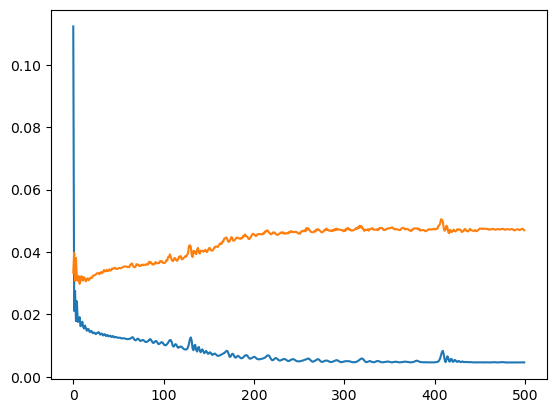

In [31]:
# Plot the metrics
plt.plot(history.history['mse'],label='train_loss')
plt.plot(history.history['val_mse'],label='test_loss')
plt.show()

In [32]:
# predictions
_,train_mse = model.evaluate(X_train,y_train,verbose=None)
_,test_mse = model.evaluate(X_test,y_test,verbose=None)

In [33]:
print(f'Train MSE -> {train_mse}\nTest MSE -> {test_mse}')

Train MSE -> 0.004568004515022039
Test MSE -> 0.04693584144115448


- The test errors are almost 10 times

In [34]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


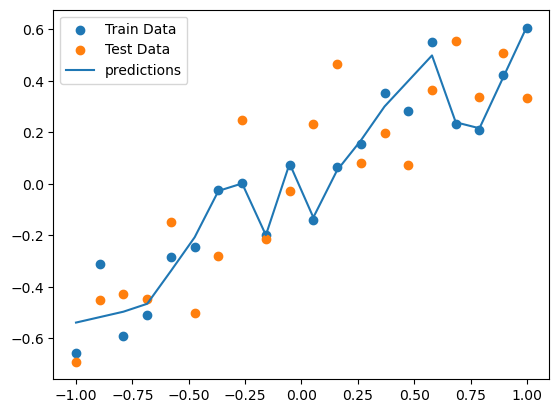

In [35]:
# plot the model
# Plot the data
plt.scatter(X_train , y_train , label='Train Data')
plt.scatter(X_test , y_test , label='Test Data')
plt.plot(X_test , y_pred , label = 'predictions')
plt.legend()
plt.show()

- Highly overfitting

### Let us ADD Dropouts

In [42]:
# Building the model
model = Sequential()
model.add(Dense(256 , activation='relu' , input_dim = 1))
model.add(Dropout(0.5))
model.add(Dense(128 , activation='relu'))
model.add(Dropout(0.5)) # added one dropout at the End layer
model.add(Dense(1 , activation='linear'))

from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam , metrics=['mse'])
history = model.fit(X_train,y_train,validation_data=(X_test,y_test) , epochs=500 , verbose=1)



Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step - loss: 0.1573 - mse: 0.1573 - val_loss: 0.0352 - val_mse: 0.0352
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0250 - mse: 0.0250 - val_loss: 0.0701 - val_mse: 0.0701
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0702 - mse: 0.0702 - val_loss: 0.0418 - val_mse: 0.0418
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0511 - mse: 0.0511 - val_loss: 0.0408 - val_mse: 0.0408
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0356 - mse: 0.0356 - val_loss: 0.0537 - val_mse: 0.0537
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0375 - mse: 0.0375 - val_loss: 0.0564 - val_mse: 0.0564
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0708 - mse: 0.0708 - val_loss: 0.0434 - val_mse: 0.0434
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0372 - mse: 0.0372 - val_loss: 0.0328 - val_mse: 0.0328
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0347 - mse:

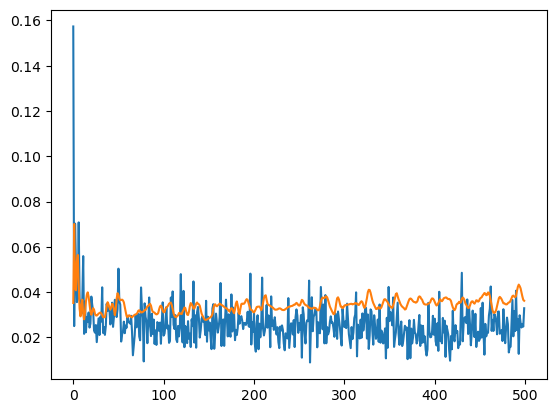

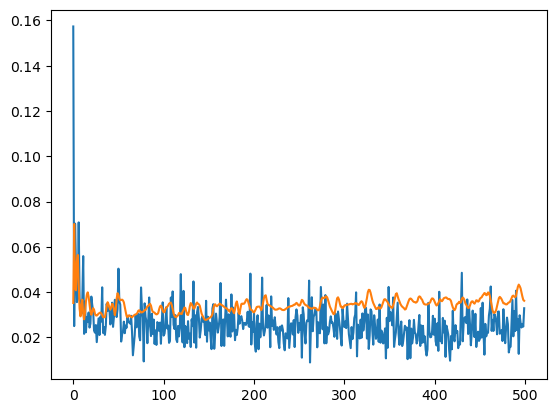

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [43]:
# Plot the metrics
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.show()

# Plot the metrics
plt.plot(history.history['mse'],label='train_loss')
plt.plot(history.history['val_mse'],label='test_loss')
plt.show()

# predictions
_,train_mse = model.evaluate(X_train,y_train,verbose=None)
_,test_mse = model.evaluate(X_test,y_test,verbose=None)

y_pred = model.predict(X_test)

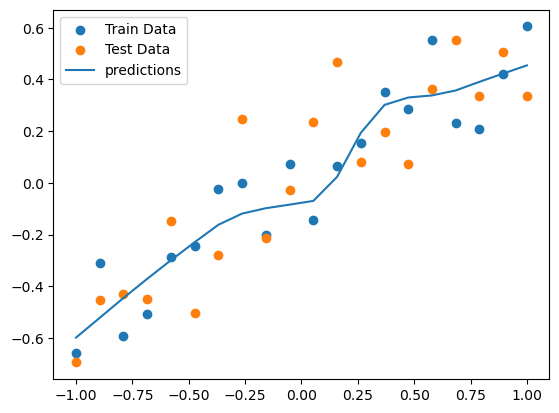

In [44]:
# plot the model

plt.scatter(X_train , y_train , label='Train Data')
plt.scatter(X_test , y_test , label='Test Data')
plt.plot(X_test , y_pred , label = 'predictions')
plt.legend()
plt.show()

### Classification Setting

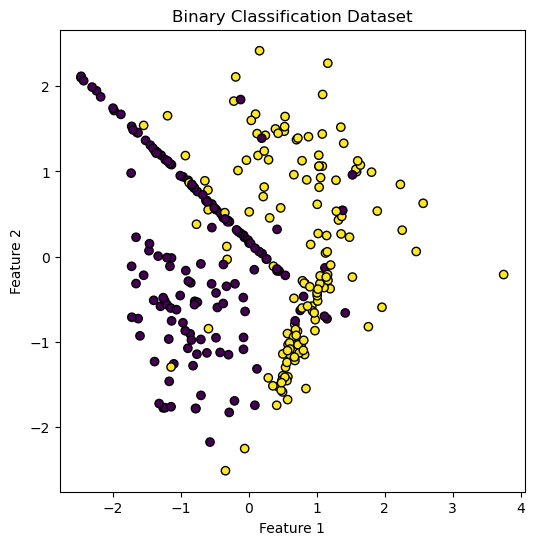

In [100]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=0.8,      # Moderate overlap
    flip_y=0.08,        # 8% label noise
    random_state=42
)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [119]:
# Building the model
from tensorflow.keras.callbacks import EarlyStopping
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=30,
    mode='auto',
    restore_best_weights=False
)
model = Sequential()
model.add(Dense(64 , activation='relu' , input_dim = 2))
model.add(Dropout(0.5))
model.add(Dense(8 , activation='relu'))
model.add(Dropout(0.5)) # added one dropout at the End layer
model.add(Dense(1 , activation='sigmoid'))

from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam , metrics=['accuracy'])
history = model.fit(X_train,y_train,validation_data=(X_test,y_test) , epochs=500 , verbose=1,callbacks=callback)



Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6190 - loss: 0.6649 - val_accuracy: 0.8667 - val_loss: 0.5290
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7476 - loss: 0.5473 - val_accuracy: 0.8556 - val_loss: 0.4249
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8143 - loss: 0.4943 - val_accuracy: 0.8778 - val_loss: 0.3715
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7810 - loss: 0.4870 - val_accuracy: 0.8667 - val_loss: 0.3607
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8238 - loss: 0.3943 - val_accuracy: 0.8667 - val_loss: 0.3573
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8190 - loss: 0.4704 - val_accuracy: 0.8667 - val_loss: 0.3538
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8000 - loss: 0.4206 - val_accuracy: 0.8667 - val_loss: 0.3500
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.4259 - val_accuracy: 0.8889 - val_loss: 0.34

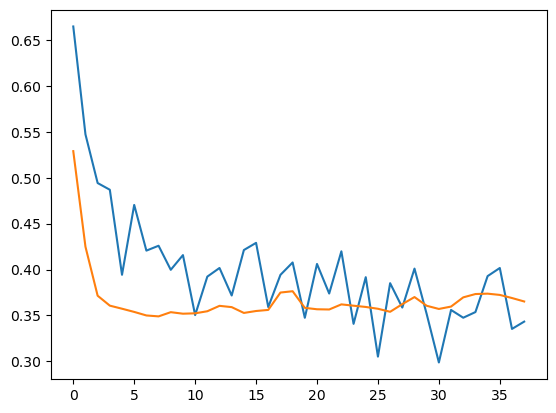

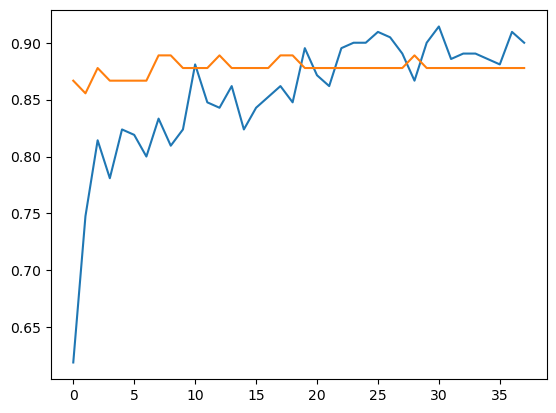

0.9095237851142883 0.8777777552604675


In [120]:
# Plot the metrics
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.show()

# Plot the metrics
plt.plot(history.history['accuracy'],label='train_loss')
plt.plot(history.history['val_accuracy'],label='test_loss')
plt.show()

# predictions
_,train_accuracy = model.evaluate(X_train,y_train,verbose=None)
_,test_accuracy = model.evaluate(X_test,y_test,verbose=None)
print(train_accuracy , test_accuracy)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 562us/step


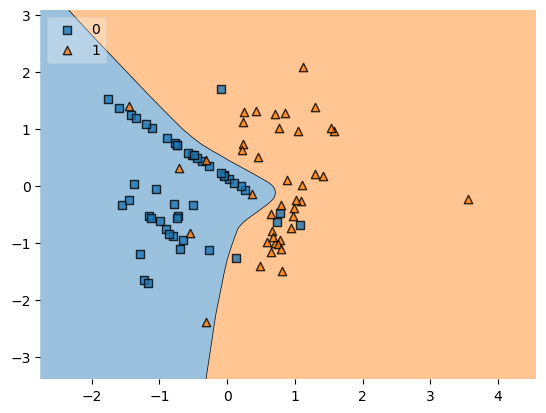

In [121]:
plot_decision_regions(X_test,y_test,clf = model, legend=2)
plt.show()